In [1]:
import pandas as pd
from pathlib import Path

base = Path(r"c:\Users\Phillip\Documents\05 - KSU (MSAI)\Fall_2025\sctt_origional_work\phase2_results")

f_7b = base / "all_forward_pass_predictions_20260221_061756_7b_regresion"

df_7b = pd.read_parquet(f_7b)

drop_cols = ['sequence_text', 'cluster_id', 'semantic_entropy', 'num_clusters',
             'ci_lower', 'ci_upper', 'ci_width', 'needs_review']
df_7b = df_7b.drop(columns=[c for c in drop_cols if c in df_7b.columns])

print(f"Shape: {df_7b.shape}")
print(f"\nColumns ({len(df_7b.columns)}):\n{df_7b.dtypes.to_string()}")
print(f"\nFirst 5 rows:")
display(df_7b.head())


Shape: (208620, 11)

Columns (11):
sample_id                str
item                     str
prompt                   str
response                 str
label_true           float64
n_generations          int64
forward_pass_type        str
forward_pass_idx       int64
sequence_score       float64
sequence_log_prob    float64
error                float64

First 5 rows:


,sample_id,item,prompt,response,label_true,n_generations,forward_pass_type,forward_pass_idx,sequence_score,sequence_log_prob,error
0,185-study_2-8722,planet,a new planet outside of our galaxy,how are conditions different than earth,0.497891,60,greedy,-1,0.513672,NaN,0.015781
1,185-study_2-8722,planet,a new planet outside of our galaxy,how are conditions different than earth,0.497891,60,sampled,0,0.416748,-0.136161,0.015781
2,185-study_2-8722,planet,a new planet outside of our galaxy,how are conditions different than earth,0.497891,60,sampled,1,0.206055,-1.081242,0.015781
3,185-study_2-8722,planet,a new planet outside of our galaxy,how are conditions different than earth,0.497891,60,sampled,2,0.576660,-0.858895,0.015781
4,185-study_2-8722,planet,a new planet outside of our galaxy,how are conditions different than earth,0.497891,60,sampled,3,0.355957,-0.447319,0.015781


In [6]:

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr

# ══════════════════════════════════════════════════════════════════════════════
# DBSCAN noise_frac vs abs_error
# Best config from grid search: features=[score, logprob], eps=0.3, min_samples=2
# ══════════════════════════════════════════════════════════════════════════════

sc_clean = df_7b['sequence_score'].replace([np.inf, -np.inf], np.nan)
lp_clean = df_7b['sequence_log_prob'].replace([np.inf, -np.inf], np.nan)

# ── greedy error per sample ───────────────────────────────────────────────────
greedy_df = df_7b[df_7b['forward_pass_type'] == 'greedy'][['sample_id', 'sequence_score']].copy()
greedy_df['sequence_score'] = sc_clean.loc[greedy_df.index]
greedy_per_sample = (greedy_df.dropna(subset=['sequence_score'])
                               .drop_duplicates('sample_id')
                               .rename(columns={'sequence_score': 'greedy_score'}))
labels_per_sample = df_7b[['sample_id', 'label_true']].drop_duplicates('sample_id')
error_df = greedy_per_sample.merge(labels_per_sample, on='sample_id')
error_df['abs_error'] = (error_df['greedy_score'] - error_df['label_true']).abs()

# ── stochastic pass arrays ────────────────────────────────────────────────────
stoch = df_7b[df_7b['forward_pass_type'] != 'greedy'].copy()
stoch['sc'] = sc_clean.loc[stoch.index]
stoch['lp'] = lp_clean.loc[stoch.index]
score_lookup   = stoch.dropna(subset=['sc']).groupby('sample_id')['sc'].apply(np.array).to_dict()
logprob_lookup = stoch.dropna(subset=['lp']).groupby('sample_id')['lp'].apply(np.array).to_dict()

valid_sids = [sid for sid in error_df['sample_id']
              if sid in score_lookup and len(score_lookup[sid]) >= 2]
error_df = error_df[error_df['sample_id'].isin(valid_sids)].reset_index(drop=True)

# ── DBSCAN with fixed params ──────────────────────────────────────────────────
EPS, MIN_SAMPLES = 0.3, 2

noise_fracs = []
for sid in error_df['sample_id']:
    sc = score_lookup[sid]
    lp = logprob_lookup.get(sid, np.array([]))
    min_n = min(len(sc), len(lp))
    if min_n < MIN_SAMPLES:
        noise_fracs.append(1.0)
        continue
    X = np.column_stack([sc[:min_n], lp[:min_n]])
    X = StandardScaler().fit_transform(X)
    labels = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit_predict(X)
    noise_fracs.append(np.mean(labels == -1))

error_df['noise_frac'] = noise_fracs

pr, _ = pearsonr(error_df['noise_frac'], error_df['abs_error'])
sr, _ = spearmanr(error_df['noise_frac'], error_df['abs_error'])

print(f"Samples: {len(error_df):,}")
print(f"DBSCAN noise_frac vs abs_error  —  Pearson r={pr:.5f}  Spearman r={sr:.5f}")
print(f"\nnoise_frac stats:\n{error_df['noise_frac'].describe().round(4)}")


Samples: 3,353
DBSCAN noise_frac vs abs_error  —  Pearson r=0.06718  Spearman r=0.05179

noise_frac stats:
count    3353.0000
mean        0.1884
std         0.0730
min         0.0000
25%         0.1333
50%         0.1833
75%         0.2333
max         0.4333
Name: noise_frac, dtype: float64


,bin,n,±0.01,±0.05,±0.10,±0.15,±0.20
0,0.1–0.2,20,5.00,25.00,60.00,90.00,100.00
1,0.2–0.3,173,9.83,47.98,76.30,90.17,95.95
2,0.3–0.4,732,9.97,48.22,77.19,89.75,95.49
3,0.4–0.5,1093,9.97,39.71,73.01,87.74,95.06
4,0.5–0.6,836,7.78,38.04,66.87,83.85,93.78
5,0.6–0.7,403,8.19,41.69,69.23,86.60,94.29
6,0.7–0.8,94,9.57,42.55,76.60,89.36,97.87
7,0.8–0.9,2,0.00,100.00,100.00,100.00,100.00


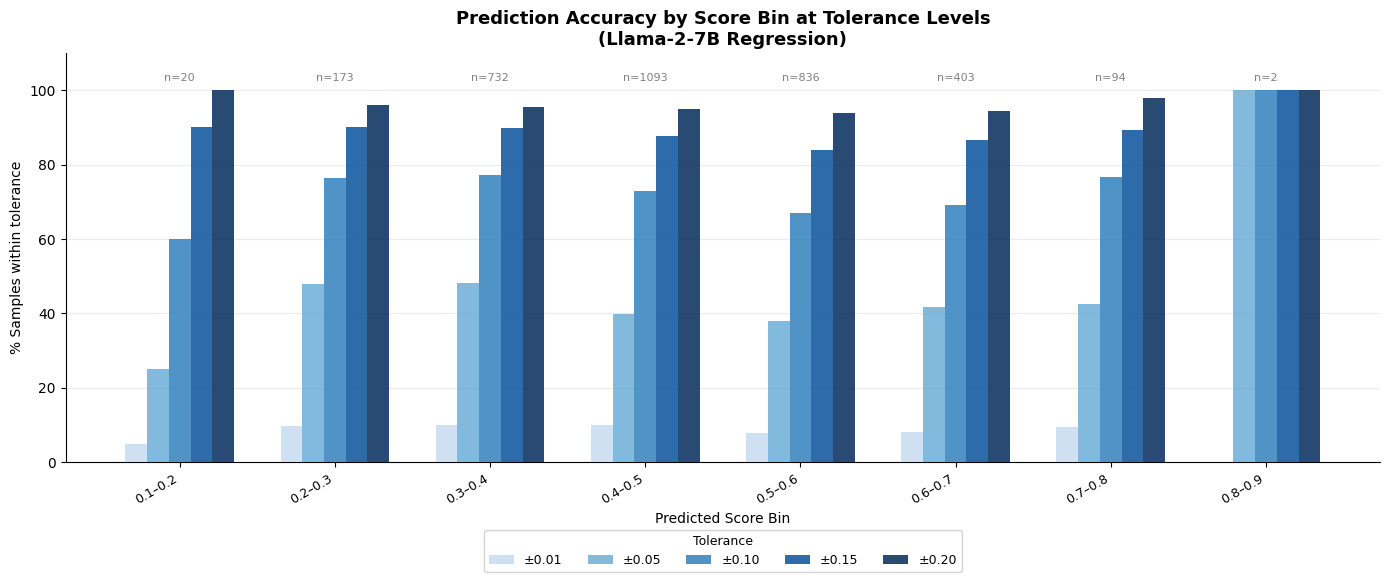

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# TOLERANCE ACCURACY PER BIN  (bar chart only)
# ══════════════════════════════════════════════════════════════════════════════

greedy_only = per_sample.drop_duplicates(subset=['sample_id']).copy()

tolerances = [0.01, 0.05, 0.10, 0.15, 0.20]
tol_labels = ['±0.01', '±0.05', '±0.10', '±0.15', '±0.20']
tol_colors = ['#c6dbef', '#6baed6', '#3182bd', '#08519c', '#022a5a']

tol_rows = []
for b_str, grp in greedy_only.groupby(greedy_only['score_bin'].astype(str), sort=True):
    row_d = {'bin': b_str, 'n': len(grp)}
    for t, lbl in zip(tolerances, tol_labels):
        row_d[lbl] = 100.0 * (grp['abs_error'] <= t).mean()
    tol_rows.append(row_d)

tol_df = pd.DataFrame(tol_rows)
display(tol_df.round(2))

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

n_bins_plot = len(tol_df)
n_tols      = len(tolerances)
bar_width   = 0.14
offsets     = np.linspace(-(n_tols - 1) / 2, (n_tols - 1) / 2, n_tols) * bar_width
x_bins      = np.arange(n_bins_plot)

for i, (lbl, col) in enumerate(zip(tol_labels, tol_colors)):
    ax.bar(x_bins + offsets[i], tol_df[lbl],
           width=bar_width, color=col, alpha=0.85, label=lbl, zorder=3)

ax.set_xticks(x_bins)
ax.set_xticklabels(tol_df['bin'], rotation=30, ha='right', fontsize=9)
ax.set_xlabel('Predicted Score Bin', fontsize=10)
ax.set_ylabel('% Samples within tolerance', fontsize=10)
ax.set_ylim(0, 110)
ax.set_title('Prediction Accuracy by Score Bin at Tolerance Levels\n'
             '(Llama-2-7B Regression)', fontsize=13, fontweight='bold')
ax.legend(title='Tolerance', fontsize=9, title_fontsize=9,
          loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5, framealpha=0.85)
ax.grid(True, axis='y', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for xi, row_t in enumerate(tol_df.itertuples()):
    ax.text(xi, 102, f'n={row_t.n}', ha='center', va='bottom', fontsize=8, color='grey')

plt.tight_layout()
plt.show()